In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, classification_report, ConfusionMatrixDisplay

In [3]:
data = pd.read_stata(r'C:\Users\Usuario\Downloads\base_a1.dta')

In [4]:
myvars2 = [
    "h13_12_d_2", "h5_12_d_2", "h15d_12_d", "h17d_12_d", "h16d_12_d", "h19d_12_d",
    "h7_12_d_2", "h11_12_d_2", "h27c_12_d_2", "h26c_12_d_2", "h28c_12_d_2", "h29c_12_d_2",
    "c64_12_d", "c1_12_d", "c2a_12_d", "c73_12_d", "c49_8_12_d", "h3_12_d_2", "c49_2_12_d",
    "c49_1_12_d", "c49_4_12_d", "c49_5_12_d", "c49_9_12_d", "c4_12_d", "c22a_12_d",
    "c25b_12_d", "c26_12_d", "c12_12_menos10_d", "c6_12_d", "c32_12_d", "c19_12_d",
    "e1b_12_d", "c69a_12_d", "fallecido_15", "c70_12_d", "c50b_12_d"
]

new_colnames = [
    "Dress", "In_out_chair", "Walk", "Eat", "Groom", "Toilet", "Stairs", "Lift",
    "Shop", "Meals", "Meds", "Finance", "Lost_weight", "Health", "H_change", "Bed",
    "Tired", "Walk_out", "Effort", "Depressed", "No_Happy", "Lone", "No_Energy",
    "High_BP", "Heart_attack", "CHF", "Stroke", "Cancer", "Diabetes", "Arthritis",
    "CLD", "Memory", "Grip", "Dead", "Anorexia", "Exercise"
]

In [5]:
df = data[myvars2]
df.columns = new_colnames

In [6]:
df_cleaned = df.dropna()

In [7]:
X = df_cleaned.drop('Dead', axis=1)
y = df_cleaned['Dead']

In [8]:
#Convertimos la variable objetivo a tipo entero para asegurar compatibilidad
y = y.astype(int)

In [9]:
print("\nDistribución de la variable objetivo 'Dead':")
print(y.value_counts())
print(f"Porcentaje de fallecidos: {y.mean() * 100:.2f}%")


Distribución de la variable objetivo 'Dead':
Dead
0    10409
1      574
Name: count, dtype: int64
Porcentaje de fallecidos: 5.23%


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [11]:
print(f"\nDatos divididos en {len(X_train)} para entrenamiento y {len(X_test)} para prueba.")



Datos divididos en 7688 para entrenamiento y 3295 para prueba.


In [12]:
k_range = range(1, 41)  # Probaremos valores de K de 1 a 40
precision_scores = []

In [13]:
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    # Calcular la precisión para la clase positiva (1 = Fallecido)
    precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    precision_scores.append(precision)

C:\Users\Usuario\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Usuario\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


In [14]:
optimal_k_precision = k_range[np.argmax(precision_scores)]
max_precision = max(precision_scores)

In [15]:
print(f"El valor óptimo de K según la Precisión es: {optimal_k_precision}")
print(f"Máxima precisión alcanzada: {max_precision:.4f}")

El valor óptimo de K según la Precisión es: 28
Máxima precisión alcanzada: 1.0000


In [16]:
sensitivity_scores = []

In [17]:
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    # Calcular la sensitividad para la clase positiva (1 = Fallecido)
    sensitivity = recall_score(y_test, y_pred, pos_label=1)
    sensitivity_scores.append(sensitivity)

In [18]:
optimal_k_sensitivity = k_range[np.argmax(sensitivity_scores)]
max_sensitivity = max(sensitivity_scores)

In [19]:
print(f"El valor óptimo de K según la Sensitividad es: {optimal_k_sensitivity}")
print(f"Máxima sensitividad alcanzada: {max_sensitivity:.4f}")

El valor óptimo de K según la Sensitividad es: 1
Máxima sensitividad alcanzada: 0.1570


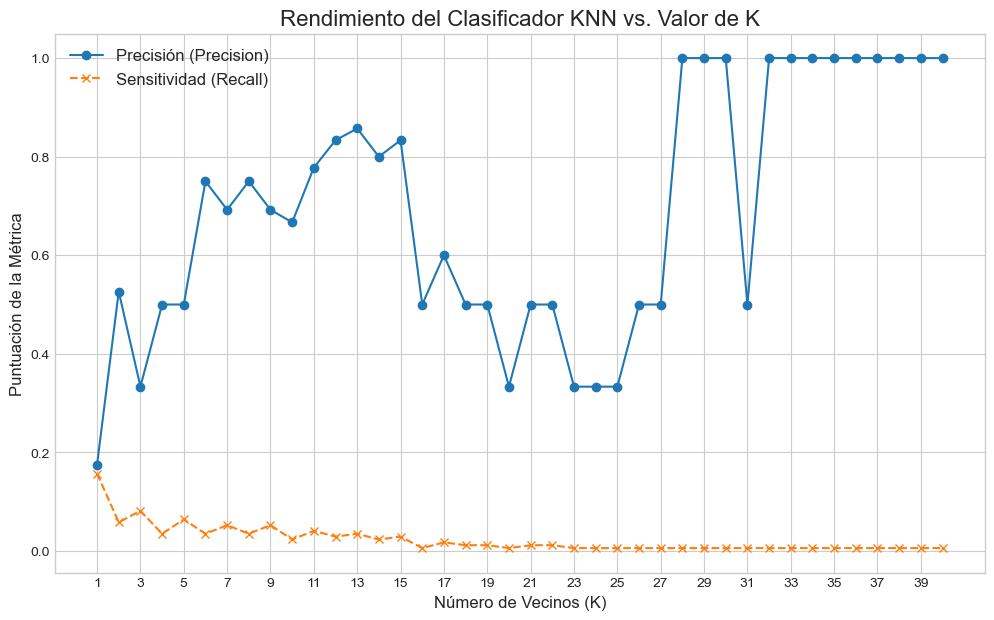

In [20]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(k_range, precision_scores, marker='o', linestyle='-', label='Precisión (Precision)')
ax.plot(k_range, sensitivity_scores, marker='x', linestyle='--', label='Sensitividad (Recall)')
ax.set_title('Rendimiento del Clasificador KNN vs. Valor de K', fontsize=16)
ax.set_xlabel('Número de Vecinos (K)', fontsize=12)
ax.set_ylabel('Puntuación de la Métrica', fontsize=12)
ax.set_xticks(np.arange(1, 41, 2))
ax.legend(fontsize=12)
plt.show()


--- Reporte de Clasificación para K óptimo según Precisión ---
Reporte para K = 28:

                  precision    recall  f1-score   support

No Fallecido (0)       0.95      1.00      0.97      3123
   Fallecido (1)       1.00      0.01      0.01       172

        accuracy                           0.95      3295
       macro avg       0.97      0.50      0.49      3295
    weighted avg       0.95      0.95      0.92      3295



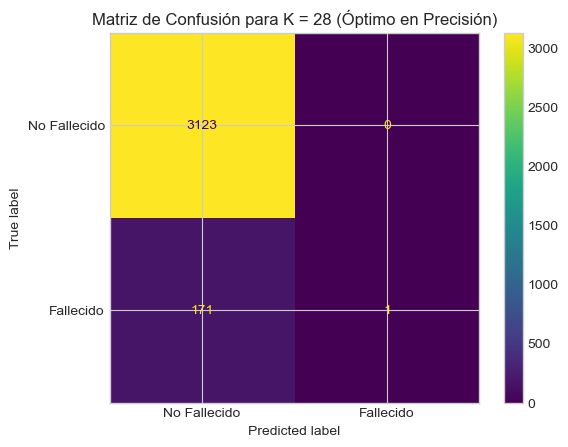

In [21]:
print("\n--- Reporte de Clasificación para K óptimo según Precisión ---")
knn_precision_model = KNeighborsClassifier(n_neighbors=optimal_k_precision)
knn_precision_model.fit(X_train, y_train)
y_pred_precision = knn_precision_model.predict(X_test)
print(f"Reporte para K = {optimal_k_precision}:\n")
print(classification_report(y_test, y_pred_precision, target_names=['No Fallecido (0)', 'Fallecido (1)']))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_precision, display_labels=['No Fallecido', 'Fallecido'])
plt.title(f'Matriz de Confusión para K = {optimal_k_precision} (Óptimo en Precisión)')
plt.show()


--- Reporte de Clasificación para K óptimo según Sensitividad ---
Reporte para K = 1:

                  precision    recall  f1-score   support

No Fallecido (0)       0.95      0.96      0.96      3123
   Fallecido (1)       0.18      0.16      0.17       172

        accuracy                           0.92      3295
       macro avg       0.56      0.56      0.56      3295
    weighted avg       0.91      0.92      0.92      3295



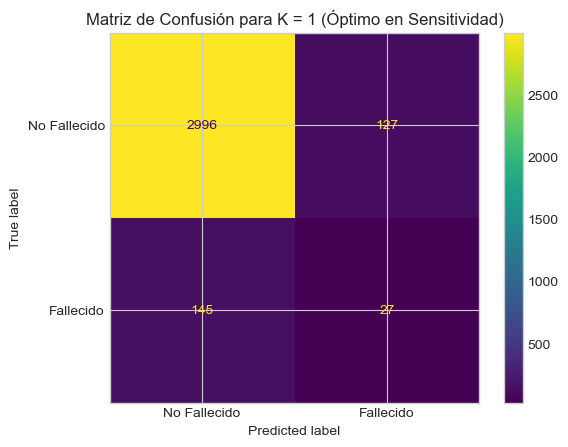

In [22]:
print("\n--- Reporte de Clasificación para K óptimo según Sensitividad ---")
knn_sensitivity_model = KNeighborsClassifier(n_neighbors=optimal_k_sensitivity)
knn_sensitivity_model.fit(X_train, y_train)
y_pred_sensitivity = knn_sensitivity_model.predict(X_test)
print(f"Reporte para K = {optimal_k_sensitivity}:\n")
print(classification_report(y_test, y_pred_sensitivity, target_names=['No Fallecido (0)', 'Fallecido (1)']))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_sensitivity, display_labels=['No Fallecido', 'Fallecido'])
plt.title(f'Matriz de Confusión para K = {optimal_k_sensitivity} (Óptimo en Sensitividad)')
plt.show()